In [2]:
import os
from pathlib import Path

import torch
from torch import nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import torch.optim as optim
import torchvision

import random
import numpy as np
import matplotlib.pyplot as plt

DATA_DIR = Path("./data")
IMAGE_SIZE = 28
CHANNELS_IMG = 1
Z_DIM = 100
NUM_CLASSES = 10  # 10 digits (0-9) for MNIST
EMBEDDING_DIM = 10  # Embedding dimension for class labels
BATCH_SIZE = 64
RANDOM_SEED = 42
LEARNING_RATE = 2e-4
NUM_EPOCHS = 10
CHECKPOINT_DIR = Path("./checkpoints_google")


DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")



In [22]:
import os
from glob import glob

# Folder path
train_dir = "./data/train"

# Common image extensions
image_extensions = ("*.jpg", "*.jpeg", "*.png", "*.bmp", "*.gif", "*.tiff", "*.webp")

# Collect all images
image_files = []
for ext in image_extensions:
    image_files.extend(glob(os.path.join(train_dir, ext)))

# Total number of images
print("Number of images:", len(image_files))


Number of images: 0


In [5]:
from PIL import Image
import numpy as np

# Pick first image
sample_path = image_files[0]
img = Image.open(sample_path)

# Convert to NumPy array
img_array = np.array(img)

# Shape info
print("Image path:", sample_path)
print("Image shape:", img_array.shape)


Image path: ./data/train/20037.png
Image shape: (28, 28)


In [6]:
height, width = img_array.shape[0], img_array.shape[1]
channels = 1 if len(img_array.shape) == 2 else img_array.shape[2]

print("Width:", width)
print("Height:", height)
print("Channels:", channels)


Width: 28
Height: 28
Channels: 1


In [3]:
def set_seed(seed: int = RANDOM_SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


def show_images(batch, n: int = 25):
    images = batch[:n].detach().cpu()
    grid_size = int(n ** 0.5)

    fig, axes = plt.subplots(grid_size, grid_size, figsize=(grid_size, grid_size))
    for i, ax in enumerate(axes.flat):
        if i >= n:
            ax.axis("off")
            continue
        ax.imshow(images[i, 0], cmap="gray")
        ax.axis("off")
    plt.tight_layout()
    plt.show()


def show_images_with_labels(batch, labels, n: int = 25):
    """Show images with their corresponding labels"""
    images = batch[:n].detach().cpu()
    labels = labels[:n].detach().cpu()
    grid_size = int(n ** 0.5)

    fig, axes = plt.subplots(grid_size, grid_size, figsize=(grid_size * 1.2, grid_size * 1.2))
    for i, ax in enumerate(axes.flat):
        if i >= n:
            ax.axis("off")
            continue
        ax.imshow(images[i, 0], cmap="gray")
        ax.set_title(f"{labels[i].item()}", fontsize=10)
        ax.axis("off")
    plt.tight_layout()
    plt.show()


def generate_specific_digits(generator, digits, num_samples_per_digit=5):
    """
    Generate specific digits using the conditional GAN.
    
    Args:
        generator: The trained generator model
        digits: List of digits to generate (e.g., [0, 1, 2] or [5, 5, 5])
        num_samples_per_digit: How many samples to generate per digit
    
    Returns:
        Generated images tensor and labels
    """
    generator.eval()
    
    # Create labels
    labels = []
    for digit in digits:
        labels.extend([digit] * num_samples_per_digit)
    
    labels = torch.tensor(labels, device=DEVICE)
    num_total = len(labels)
    
    # Generate noise
    noise = torch.randn(num_total, Z_DIM, device=DEVICE)
    
    # Generate images
    with torch.no_grad():
        fake_imgs = generator(noise, labels)
    
    print(f"Generated {num_total} images for digits: {digits}")
    print(f"Labels: {labels.cpu().numpy()}")
    
    return fake_imgs, labels


def weights_init(m):
    if isinstance(m, (nn.Conv2d, nn.ConvTranspose2d, nn.Linear)):
        nn.init.normal_(m.weight.data, 0.0, 0.02)
        if m.bias is not None:
            nn.init.constant_(m.bias.data, 0.0)
    elif isinstance(m, nn.BatchNorm2d):
        nn.init.normal_(m.weight.data, 1.0, 0.02)
        nn.init.constant_(m.bias.data, 0.0)


set_seed()


In [4]:
transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
])

train_dataset = datasets.ImageFolder(
    root=DATA_DIR,
    transform=transform,
)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True
)

real_imgs, real_labels = next(iter(train_loader))
print("Batch images shape:", real_imgs.shape)
print("Batch labels shape:", real_labels.shape)

show_images(real_imgs)


FileNotFoundError: Couldn't find any class folder in data.

In [5]:
class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()
        # Embedding for class labels
        self.label_embedding = nn.Embedding(NUM_CLASSES, IMAGE_SIZE * IMAGE_SIZE)
        
        # Input: image (1 channel) + label embedding (1 channel) = 2 channels
        self.net = nn.Sequential(
            nn.Conv2d(2, 64, kernel_size=3, stride=2, padding=1),
            nn.BatchNorm2d(64),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(64, 64, kernel_size=3, stride=2, padding=1),
            nn.BatchNorm2d(64),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Flatten(),
            nn.Linear(64 * 7 * 7, 1),
            nn.Sigmoid(),
        )

    def forward(self, x, labels):
        # Embed labels and reshape to image format
        label_embed = self.label_embedding(labels)  # [N, 784]
        label_embed = label_embed.view(-1, 1, IMAGE_SIZE, IMAGE_SIZE)  # [N, 1, 28, 28]
        
        # Concatenate image and label embedding
        x = torch.cat([x, label_embed], dim=1)  # [N, 2, 28, 28]
        return self.net(x)


class Generator(nn.Module):
    def __init__(self):
        super().__init__()
        # Embedding for class labels
        self.label_embedding = nn.Embedding(NUM_CLASSES, EMBEDDING_DIM)
        
        # Input: noise (Z_DIM) + label embedding (EMBEDDING_DIM)
        self.fc = nn.Sequential(
            nn.Linear(Z_DIM + EMBEDDING_DIM, 128 * 7 * 7),
            nn.ReLU(inplace=True),
        )

        self.conv = nn.Sequential(
            nn.ConvTranspose2d(128, 128, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),

            nn.ConvTranspose2d(128, 128, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),

            nn.Conv2d(128, 1, kernel_size=7, stride=1, padding=3),
            nn.Sigmoid(),
        )

    def forward(self, z, labels):
        # Embed labels
        label_embed = self.label_embedding(labels)  # [N, EMBEDDING_DIM]
        
        # Concatenate noise and label embedding
        x = torch.cat([z, label_embed], dim=1)  # [N, Z_DIM + EMBEDDING_DIM]
        x = self.fc(x)                           # [N, 128*7*7]
        x = x.view(-1, 128, 7, 7)                # [N, 128, 7, 7]
        x = self.conv(x)                         # [N, 1, 28, 28]
        return x


discriminator = Discriminator().to(DEVICE)
generator = Generator().to(DEVICE)

discriminator.apply(weights_init)
generator.apply(weights_init)

print(discriminator)
print(generator)


Discriminator(
  (label_embedding): Embedding(10, 784)
  (net): Sequential(
    (0): Conv2d(2, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): LeakyReLU(negative_slope=0.2, inplace=True)
    (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): LeakyReLU(negative_slope=0.2, inplace=True)
    (6): Flatten(start_dim=1, end_dim=-1)
    (7): Linear(in_features=3136, out_features=1, bias=True)
    (8): Sigmoid()
  )
)
Generator(
  (label_embedding): Embedding(10, 10)
  (fc): Sequential(
    (0): Linear(in_features=110, out_features=6272, bias=True)
    (1): ReLU(inplace=True)
  )
  (conv): Sequential(
    (0): ConvTranspose2d(128, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)


In [25]:
torch.save({
    "generator_state_dict": generator.state_dict()
}, "./checkpoints_google/gan_epoch_1.pt")


Testing checkpoint: ./checkpoints_google/gan_epoch_1.pt
Generated digits: [3 8 1 7 5 1 4 2 2 7]


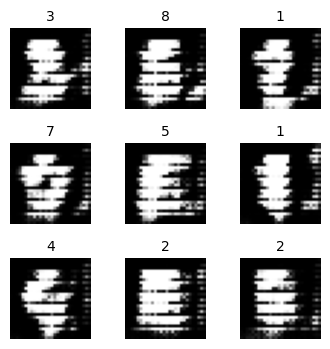

Testing checkpoint: ./checkpoints_google/gan_epoch_15.pt
Generated digits: [3 7 1 8 9 5 3 7 5 8]


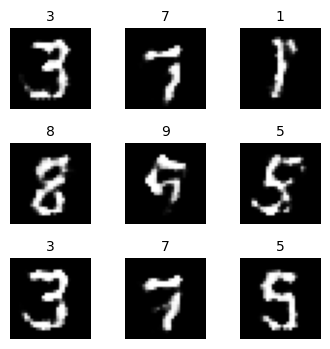

Testing checkpoint: ./checkpoints_google/gan_epoch_20.pt
Generated digits: [9 2 7 0 2 8 4 0 2 8]


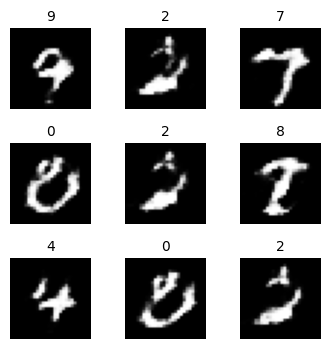

Testing checkpoint: ./checkpoints_google/gan_epoch_30.pt
Generated digits: [7 6 2 5 6 0 1 0 8 7]


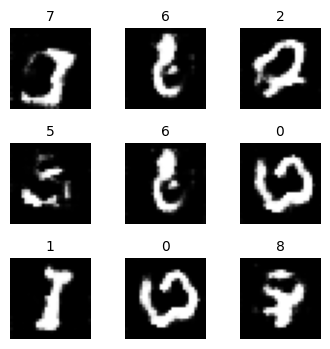

Testing checkpoint: ./checkpoints_google/gan_epoch_55.pt
Generated digits: [7 7 8 7 7 5 1 9 3 1]


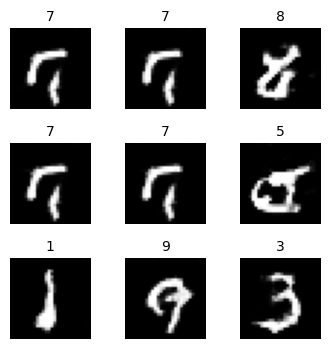

Testing checkpoint: ./checkpoints_google/gan_epoch_80.pt
Generated digits: [9 5 5 2 5 6 8 0 7 9]


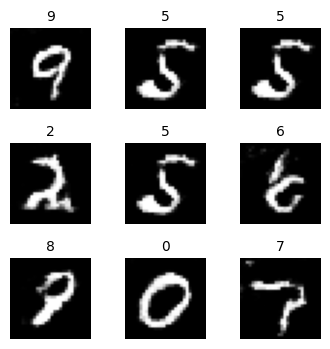

Testing checkpoint: ./checkpoints_google/gan_epoch_100.pt
Generated digits: [3 4 4 0 3 1 3 6 7 8]


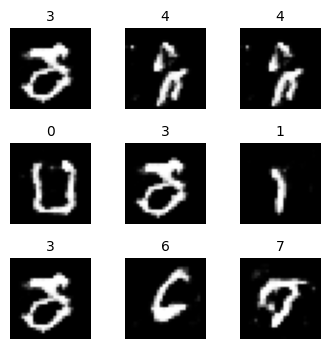

In [18]:
checpoints_to_test = [
    './checkpoints_google/gan_epoch_1.pt',
    './checkpoints_google/gan_epoch_15.pt',
    './checkpoints_google/gan_epoch_20.pt',
    './checkpoints_google/gan_epoch_30.pt',
    './checkpoints_google/gan_epoch_55.pt',
    './checkpoints_google/gan_epoch_80.pt',
    './checkpoints_google/gan_epoch_100.pt'
]


for checkpoint_path in checpoints_to_test:

    print(f"Testing checkpoint: {checkpoint_path}")
    checkpoint = torch.load(checkpoint_path, map_location=DEVICE)

    generator.load_state_dict(checkpoint["generator_state_dict"])
    generator.to(DEVICE)
    generator.eval()

    num_samples = 10
    noise = torch.randn(num_samples, Z_DIM, device=DEVICE)

    # Option 1: Generate random digits
    random_labels = torch.randint(0, NUM_CLASSES, (num_samples,), device=DEVICE)

    with torch.no_grad():
        fake_imgs = generator(noise, random_labels)

    print(f"Generated digits: {random_labels.cpu().numpy()}")
    show_images_with_labels(fake_imgs, random_labels, n=num_samples)


Generating only 3s:
Generated 25 images for digits: [3]
Labels: [3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3]


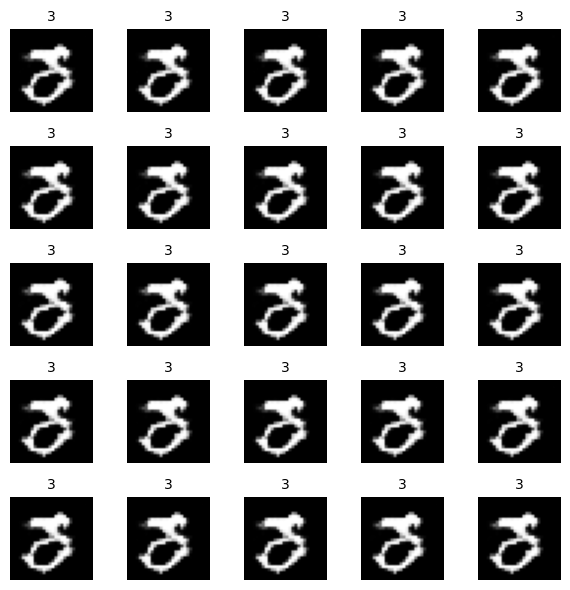

In [12]:
# Example 1: Generate 25 images of digit "3"
print("Generating only 3s:")
fake_imgs, labels = generate_specific_digits(generator, [3], num_samples_per_digit=25)
show_images_with_labels(fake_imgs, labels, n=25)


Generating 5 samples of each digit 0-9:
Generated 50 images for digits: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
Labels: [0 0 0 0 0 1 1 1 1 1 2 2 2 2 2 3 3 3 3 3 4 4 4 4 4 5 5 5 5 5 6 6 6 6 6 7 7
 7 7 7 8 8 8 8 8 9 9 9 9 9]


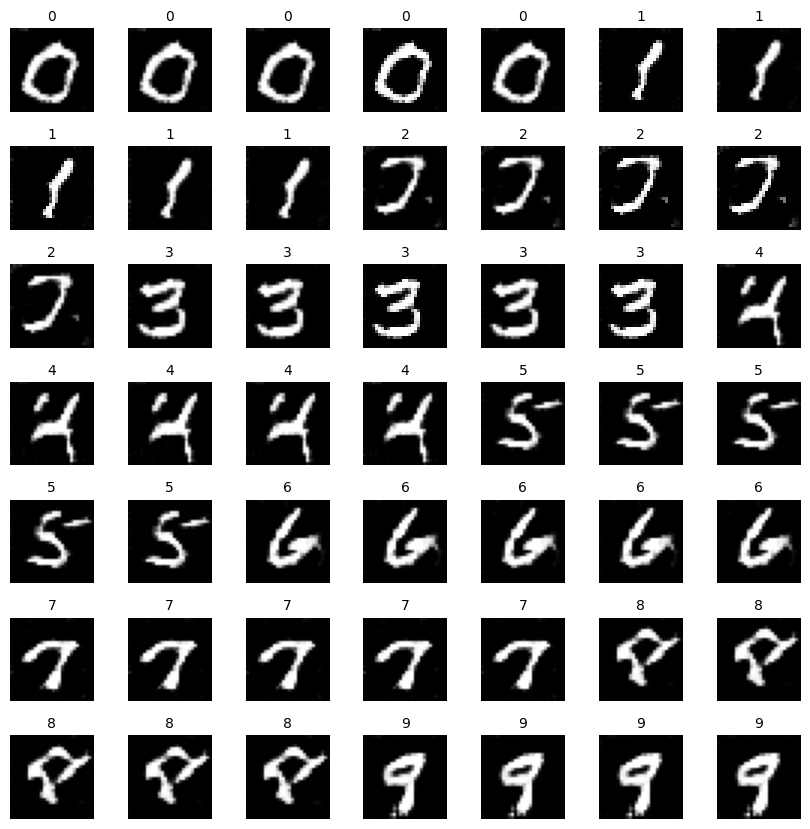

In [9]:
# Example 2: Generate 5 of each digit 0-9
print("Generating 5 samples of each digit 0-9:")
fake_imgs, labels = generate_specific_digits(generator, list(range(10)), num_samples_per_digit=5)
show_images_with_labels(fake_imgs, labels, n=50)


Generating mixed digits [1, 5, 9]:
Generated 30 images for digits: [1, 5, 9]
Labels: [1 1 1 1 1 1 1 1 1 1 5 5 5 5 5 5 5 5 5 5 9 9 9 9 9 9 9 9 9 9]


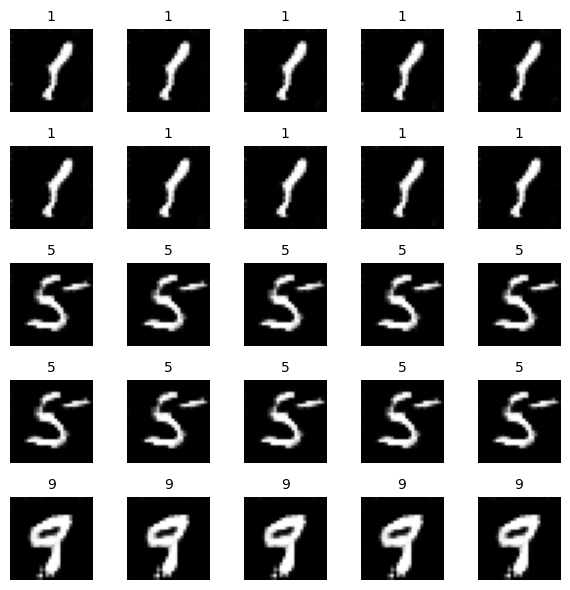

In [10]:
# Example 3: Generate mixed digits (1, 5, 9)
print("Generating mixed digits [1, 5, 9]:")
fake_imgs, labels = generate_specific_digits(generator, [1, 5, 9], num_samples_per_digit=10)
show_images_with_labels(fake_imgs, labels, n=30)


Testing diversity for digit 7:


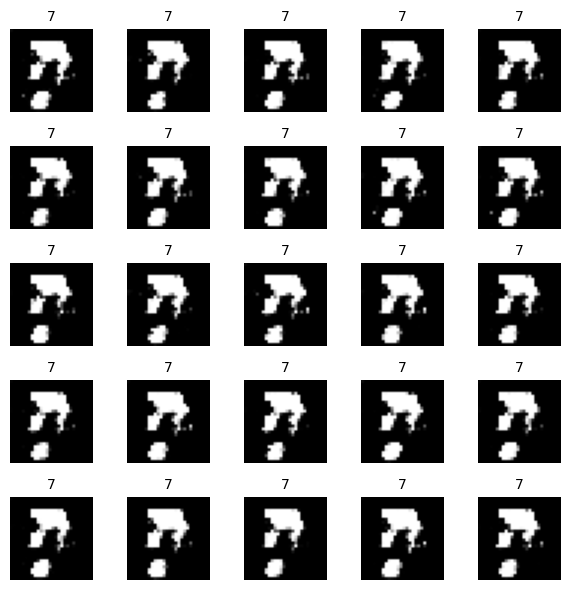

If all images look very similar, you have mode collapse!


In [56]:
# Diagnostic: Generate the same digit multiple times with different noise
# This will show you how much diversity the model can produce
print("Testing diversity for digit 7:")
num_variations = 25
fixed_label = torch.full((num_variations,), 7, device=DEVICE)
random_noise = torch.randn(num_variations, Z_DIM, device=DEVICE)

with torch.no_grad():
    variations = generator(random_noise, fixed_label)

show_images_with_labels(variations, fixed_label, n=num_variations)
print("If all images look very similar, you have mode collapse!")


In [ ]:
"""
SOLUTIONS TO IMPROVE DIVERSITY:

1. REDUCE EMBEDDING_DIM:
   Change EMBEDDING_DIM from 50 to 10 or 20 in main.ipynb
   This gives the random noise more influence relative to the label

2. INCREASE Z_DIM:
   Change Z_DIM from 100 to 200 or 300
   More dimensions in the noise vector = more potential for diversity

3. TRAIN LONGER:
   Mode collapse often improves with more training epochs
   Try training for 20-50 epochs instead of 10

4. USE DIFFERENT LOSS:
   Consider using Wasserstein GAN loss instead of BCE
   WGAN is more stable and reduces mode collapse

5. ADD NOISE TO DISCRIMINATOR:
   Add small random noise to real images during training
   This prevents the discriminator from being too confident

6. CHECK YOUR CHECKPOINTS:
   Make sure you're using checkpoints from the CONDITIONAL GAN
   Old unconditional checkpoints won't work properly with labels
"""
print("See the solutions in the cell output above!")
